### 0. Set vars and MAP drives

In [2]:
import os

%env LOCAL_PROJECT_DIR=local_project_dir

os.environ["LOCAL_DATA_DIR"] = os.path.join(os.getenv("LOCAL_PROJECT_DIR", os.getcwd()), "data")
os.environ["LOCAL_EXPERIMENT_DIR"] = os.path.join(os.getenv("LOCAL_PROJECT_DIR", os.getcwd()), "classification")
os.environ["LOCAL_SPECS_DIR"] = os.path.join(os.getcwd(), "specs")

%env KEY=dHFmaTA4amVydDR0cG8xOTcwM2FoZW5vMmI6ZjZhOTRmYzUtMjkzOS00NTk2LThkNWEtYzk0NDM1Y2EzZDg3
%env NUM_GPUS=1
%env SPECS_DIR=/workspace/tao-experiments/classification/specs
%env USER_EXPERIMENT_DIR=/workspace/tao-experiments/classification
%env DATA_DOWNLOAD_DIR=/workspace/tao-experiments/data

env: LOCAL_PROJECT_DIR=local_project_dir
env: KEY=dHFmaTA4amVydDR0cG8xOTcwM2FoZW5vMmI6ZjZhOTRmYzUtMjkzOS00NTk2LThkNWEtYzk0NDM1Y2EzZDg3
env: NUM_GPUS=1
env: SPECS_DIR=/workspace/tao-experiments/classification/specs
env: USER_EXPERIMENT_DIR=/workspace/tao-experiments/classification
env: DATA_DOWNLOAD_DIR=/workspace/tao-experiments/data


### visualize spot common

In [4]:
import matplotlib.pyplot as plt
from PIL import Image 
from glob import glob
import os

LOCAL_DATA_DIR = os.environ.get('LOCAL_DATA_DIR')

images = glob(os.path.join(LOCAL_DATA_DIR, 'stage1_spot_tests/*'))
w, h = 200, 200
fig = plt.figure(figsize=(30,30))
columns = 10
rows = 6
for i in range(len(images)):
  # this is index: col and row
  # print(i, i%columns, int(i/columns))
  ax = fig.add_subplot(rows, columns, i+1)
  img = Image.open(images[i])
  img = img.resize((w,h), Image.ANTIALIAS)
  plt.imshow(img)
  ax.set_title(images[i].split('|')[-2], fontsize=40)

/home/kmilo8346/pactolus_belt_vision/classification


In [15]:
# lets convert them first
import os
from PIL import Image
from glob import glob
from tqdm import tqdm

LOCAL_DATA_DIR = os.environ.get('LOCAL_DATA_DIR')
images = glob(os.path.join(LOCAL_DATA_DIR, 'stage1_spot_tests/*'))

for image in tqdm(images):
  im = Image.open(image)
  im.save(image + '.jpeg', 'JPEG')
  os.remove(image)

100%|██████████| 58/58 [00:00<00:00, 740.75it/s]


In [16]:
# set best epoch
%set_env EPOCH=046

env: EPOCH=046


In [17]:
!tao classification inference -e $SPECS_DIR/stage1_classification_retrain_spec.cfg \
                          -m $USER_EXPERIMENT_DIR/stage1_output_retrain/weights/resnet_$EPOCH.tlt \
                          -k $KEY -b 32 -d $DATA_DOWNLOAD_DIR/stage1_spot_tests \
                          -cm $USER_EXPERIMENT_DIR/stage1_output_retrain/classmap.json

2022-02-25 15:34:40,019 [INFO] root: Registry: ['nvcr.io']
2022-02-25 15:34:40,076 [INFO] tlt.components.instance_handler.local_instance: Running command in container: nvcr.io/nvidia/tao/tao-toolkit-tf:v3.21.11-tf1.15.5-py3
Matplotlib created a temporary config/cache directory at /tmp/matplotlib-z0ry5lho because the default path (/.config/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Using TensorFlow backend.
Using TensorFlow backend.

2022-02-25 15:34:50,603 [WARNING] tensorflow: From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:517: The name tf.placeholder is deprecated. Please use tf.compat.v1.placeholder instead.


2022-02-25 15:34:50,615 [WARNING] tensorflow: From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:4138: The name tf.random_uniform is d

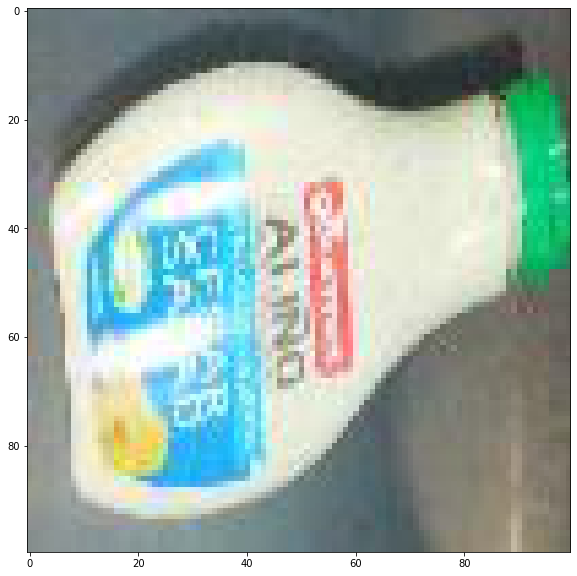

In [5]:
# visualize single image
import matplotlib.pyplot as plt
from PIL import Image
import os

pic = Image.open(os.getenv('LOCAL_DATA_DIR') + '/stage1_spot_tests/f25062c6-24c8-460c-a8cf-910ec2db0b62|07802410001423|99.jpeg')
plt.figure(figsize= (10, 10))

plt.imshow(pic)